# Heart Disease Project Part 3: Basic Machine Learning Implementation

Date: 05-30-2026

Student ID: Mormoo5363

In [2]:
import pandas as pd
import numpy as np

from datetime import datetime
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    mean_squared_error,
    r2_score,
    silhouette_score
)

from sklearn.svm import SVC
from sklearn.cluster import KMeans
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "Mormoo5363"

display(Markdown("## Load and Preprocess Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Load dataset
data = pd.read_csv("heart_disease_uci.csv")

display(data.head())
print("Dataset shape:", data.shape)

# Drop ID because it is only an identifier
data = data.drop(columns=["id"])

# Fill missing numeric values with median
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Fill missing categorical values with mode
categorical_cols = data.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Create binary heart disease target for classification
data["heart_disease"] = data["num"].apply(lambda x: 1 if x > 0 else 0)

# One-hot encode categorical variables
encoded_data = pd.get_dummies(data, drop_first=True)

print("\nMissing values after cleaning:")
print(encoded_data.isnull().sum().sum())

print("\nEncoded dataset shape:")
print(encoded_data.shape)

display(encoded_data.head())

## Load and Preprocess Dataset

Date: 2026-05-30

Student ID: Mormoo5363

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset shape: (920, 16)

Missing values after cleaning:
0

Encoded dataset shape:
(920, 23)


C:\Users\Morgan Moore\AppData\Local\Temp\ipykernel_17252\1494887875.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include=["object"]).columns


,age,trestbps,chol,thalch,oldpeak,ca,num,heart_disease,sex_Male,dataset_Hungary,...,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,0,True,False,...,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,2,1,True,False,...,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,1,True,False,...,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,0,True,False,...,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,0,False,False,...,False,False,False,False,False,False,False,True,True,False


In [3]:
display(Markdown("## Classification Task: SVM Model"))
display(Markdown("### Goal: Predict whether a patient has heart disease"))

# Features and target
X_class = encoded_data.drop(columns=["num", "heart_disease"])
y_class = encoded_data["heart_disease"]

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.30,
    random_state=42
)

# Scale features
scaler_class = StandardScaler()

X_train_class_scaled = scaler_class.fit_transform(X_train_class)
X_test_class_scaled = scaler_class.transform(X_test_class)

# Model design explanation
display(Markdown("""
**Model Design:**  
For the classification task, I used a Support Vector Machine classifier.  
The goal is to predict whether a patient has heart disease or not.  
I used an RBF kernel because it can handle non-linear relationships in the data.  
The main evaluation metrics are accuracy, precision, recall, and F1-score.
"""))

# Train model
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_class_scaled, y_train_class)

# Predictions
y_pred_class = svm_model.predict(X_test_class_scaled)

# Evaluation
class_accuracy = accuracy_score(y_test_class, y_pred_class)
class_precision = precision_score(y_test_class, y_pred_class)
class_recall = recall_score(y_test_class, y_pred_class)
class_f1 = f1_score(y_test_class, y_pred_class)

print(f"Accuracy: {class_accuracy:.4f}")
print(f"Precision: {class_precision:.4f}")
print(f"Recall: {class_recall:.4f}")
print(f"F1 Score: {class_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

## Classification Task: SVM Model

### Goal: Predict whether a patient has heart disease


**Model Design:**  
For the classification task, I used a Support Vector Machine classifier.  
The goal is to predict whether a patient has heart disease or not.  
I used an RBF kernel because it can handle non-linear relationships in the data.  
The main evaluation metrics are accuracy, precision, recall, and F1-score.


Accuracy: 0.8514
Precision: 0.8758
Recall: 0.8590
F1 Score: 0.8673

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       120
           1       0.88      0.86      0.87       156

    accuracy                           0.85       276
   macro avg       0.85      0.85      0.85       276
weighted avg       0.85      0.85      0.85       276



## Classification Confusion Matrix

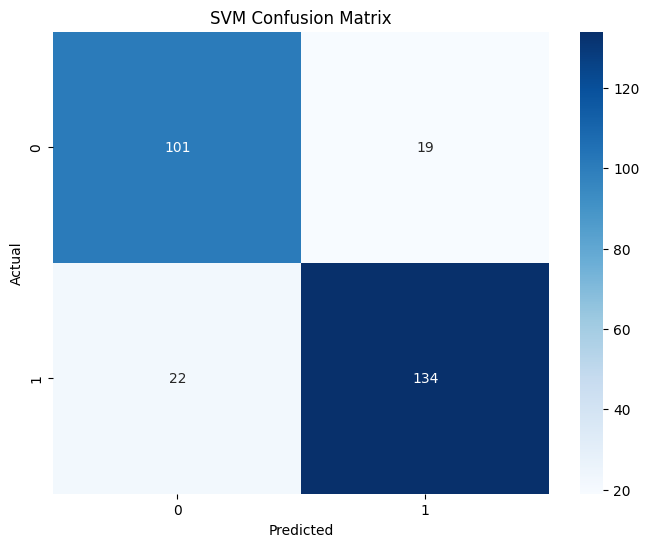

In [4]:
from sklearn.metrics import confusion_matrix

display(Markdown("## Classification Confusion Matrix"))

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [5]:
display(Markdown("## Regression Task: XGBoost Regressor"))
display(Markdown("### Goal: Predict patient cholesterol levels"))

# Drop rows where cholesterol is 0 because 0 is not clinically meaningful
regression_data = encoded_data[encoded_data["chol"] > 0].copy()

# Features and target
X_reg = regression_data.drop(columns=["chol", "num", "heart_disease"])
y_reg = regression_data["chol"]

# Split data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=42
)

display(Markdown("""
**Model Design:**  
For the regression task, I used XGBoost Regressor to predict cholesterol levels.  
This model was selected because it handles complex relationships between medical features better than a basic linear model.  
I used a moderate number of trees and a small learning rate to balance performance and avoid overfitting.  
The main evaluation metrics are Mean Squared Error and R-squared.
"""))

# Train model
xgb_regressor = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_regressor.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_reg = xgb_regressor.predict(X_test_reg)

# Evaluation
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

## Regression Task: XGBoost Regressor

### Goal: Predict patient cholesterol levels


**Model Design:**  
For the regression task, I used XGBoost Regressor to predict cholesterol levels.  
This model was selected because it handles complex relationships between medical features better than a basic linear model.  
I used a moderate number of trees and a small learning rate to balance performance and avoid overfitting.  
The main evaluation metrics are Mean Squared Error and R-squared.


Mean Squared Error: 3535.4599
Root Mean Squared Error: 59.4597
R-squared Score: -0.0940


## Regression Visualization: Actual vs Predicted Cholesterol

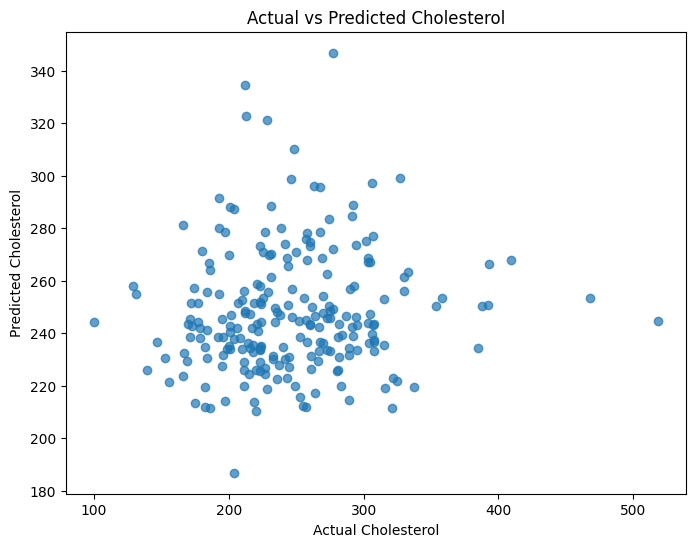

In [6]:
display(Markdown("## Regression Visualization: Actual vs Predicted Cholesterol"))

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.7
)

plt.xlabel("Actual Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Actual vs Predicted Cholesterol")

plt.show()

In [7]:
display(Markdown("## Clustering Task: K-Means Patient Risk Groups"))

# Select features related to risk stratification
cluster_features = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak",
    "ca"
]

X_cluster = encoded_data[cluster_features].copy()

# Scale clustering features
scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

display(Markdown("""
**Model Design:**  
For the clustering task, I used K-Means clustering to group patients based on cardiovascular risk factors.  
The selected features include age, resting blood pressure, cholesterol, maximum heart rate, oldpeak, and number of major vessels.  
I started with three clusters because the goal is to identify general low, moderate, and higher-risk patient groups.
"""))

# Train K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Evaluation
sil_score = silhouette_score(X_cluster_scaled, cluster_labels)

print(f"Number of clusters: 3")
print(f"Silhouette Score: {sil_score:.4f}")

# Add labels to dataframe
clustered_data = encoded_data.copy()
clustered_data["cluster"] = cluster_labels

display(clustered_data[cluster_features + ["cluster"]].head())

## Clustering Task: K-Means Patient Risk Groups


**Model Design:**  
For the clustering task, I used K-Means clustering to group patients based on cardiovascular risk factors.  
The selected features include age, resting blood pressure, cholesterol, maximum heart rate, oldpeak, and number of major vessels.  
I started with three clusters because the goal is to identify general low, moderate, and higher-risk patient groups.


Number of clusters: 3
Silhouette Score: 0.2123


,age,trestbps,chol,thalch,oldpeak,ca,cluster
0,63,145.0,233.0,150.0,2.3,0.0,1
1,67,160.0,286.0,108.0,1.5,3.0,2
2,67,120.0,229.0,129.0,2.6,2.0,2
3,37,130.0,250.0,187.0,3.5,0.0,0
4,41,130.0,204.0,172.0,1.4,0.0,0


## Clustering Visualization

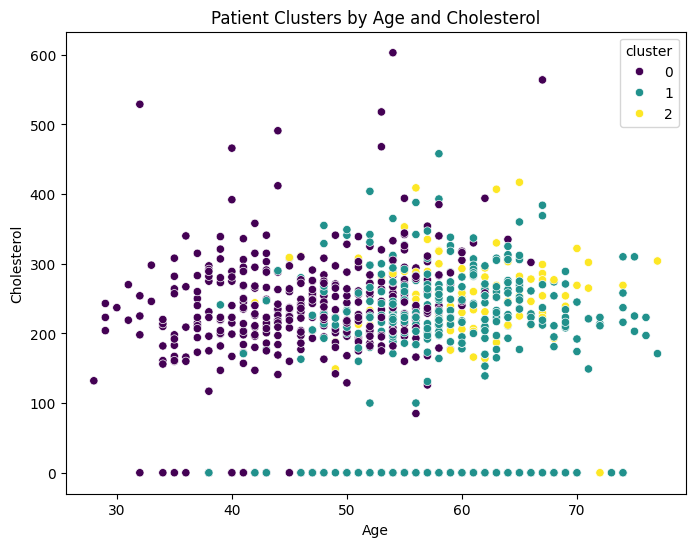

In [8]:
display(Markdown("## Clustering Visualization"))

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=clustered_data["age"],
    y=clustered_data["chol"],
    hue=clustered_data["cluster"],
    palette="viridis"
)

plt.title("Patient Clusters by Age and Cholesterol")
plt.xlabel("Age")
plt.ylabel("Cholesterol")

plt.show()

## Model Performance Summary

### Classification Task

For the classification task, I used an SVM model to predict whether a patient had heart disease. I chose SVM because it works well for classification problems and can handle non-linear patterns when using the RBF kernel. The initial hyperparameters were C = 1.0, gamma = "scale", and kernel = "rbf". These were selected because they are standard starting values and usually provide a balanced baseline model.

### Regression Task

For the regression task, I used XGBoost Regressor to predict cholesterol levels. I chose this model because cholesterol prediction may involve non-linear relationships between several medical features. The initial hyperparameters were n_estimators = 100, learning_rate = 0.1, and max_depth = 3. These values were selected because they provide a reasonable starting point without making the model too complex.

### Clustering Task

For the clustering task, I used K-Means clustering to group patients based on cardiovascular risk factors. I selected three clusters because the goal was to group patients into general low, moderate, and higher-risk groups. The clustering model was evaluated using the silhouette score, which helps show how well-separated the clusters are.

Overall, these three models helped address the classification, regression, and clustering goals from the earlier project phases. The classification model focused on predicting heart disease presence, the regression model estimated cholesterol levels, and the clustering model grouped patients with similar cardiovascular risk profiles.